In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [63]:
df=pd.read_csv('height-weight.csv')

In [64]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

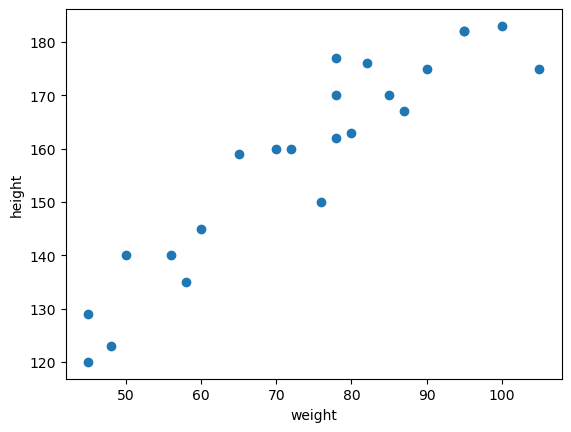

In [65]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('weight')
plt.ylabel('height')

In [66]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [67]:
import seaborn as sns


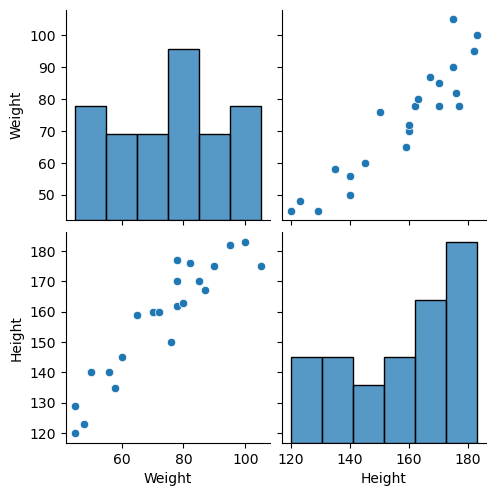

In [68]:
sns.pairplot(df)

In [69]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [70]:
X=df[['Weight']]
np.array(X).shape

## Independent Feature - should be 2 dimensional

(23, 1)

In [71]:
X_series = df['Weight']
np.array(X_series).shape

(23,)

In [72]:
y=df['Height']
y # Dependent var. can be 1-dimensional or series

0     120
1     135
2     123
3     145
4     160
5     162
6     163
7     175
8     182
9     170
10    176
11    182
12    175
13    183
14    170
15    177
16    140
17    159
18    150
19    167
20    129
21    140
22    160
Name: Height, dtype: int64

In [73]:
# Train Test Split

from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [74]:
X_train.shape

(17, 1)

In [75]:
from sklearn.preprocessing import StandardScaler

In [76]:
scaler = StandardScaler()

In [77]:
X_train=scaler.fit_transform(X_train)

In [78]:
X_test = scaler.transform(X_test)

In [79]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [80]:
# Apply Simple Linear Regression

from sklearn.linear_model import LinearRegression

In [81]:
regression = LinearRegression(n_jobs=-1)

In [82]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [83]:
print(f"Coefficient or slope - beta1 : {regression.coef_}")

Coefficient or slope - beta1 : [17.2982057]


In [84]:
print(f"Intercept - beta0 : {regression.intercept_}")

Intercept - beta0 : 156.47058823529412


In [85]:
# now - plotting best-fit line

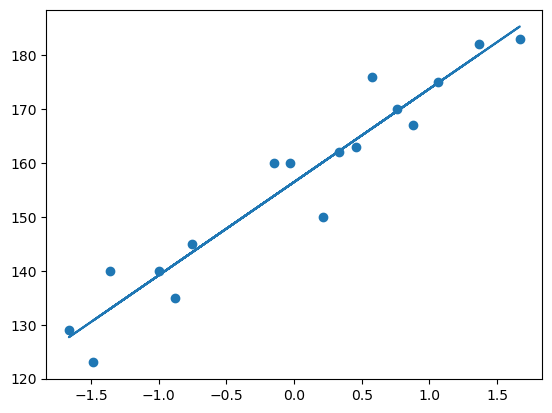

In [86]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

Prediction of test-data : 
predicted ht o/p = intercept_ + coef_(Weights)
y_pred = 156.470 + 17.29(X_test)

In [87]:
# Prediction for test data

y_pred = regression.predict(X_test)

In [88]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Error': y_test - y_pred})
print(comparison.head())

    Actual   Predicted      Error
15     177  162.264997  14.735003
9      170  162.264997   7.735003
0      120  127.683471  -7.683471
8      182  180.079723   1.920277
17     159  148.641972  10.358028


In [89]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [90]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.665125886795005
10.716374991212605


## R-squre - model performance

In [91]:
from sklearn.metrics import r2_score

In [93]:
score = r2_score(y_test,y_pred)
score

0.7360826717981276

## Adjusted - R-square: 

Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]

In [94]:
# OLS Linear Regression

import statsmodels.api as sm

In [95]:
model = sm.OLS(y_train,X_train).fit()

In [96]:
prediction = model.predict(X_test)
prediction

array([  5.79440897,   5.79440897, -28.78711691,  23.60913442,
        -7.82861638,  34.08838469])

In [97]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Mon, 16 Feb 2026   Prob (F-statistic):                       0.664
Time:                        01:50:05   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [98]:
## prediction for new data

regression.predict(scaler.transform([[72]]))

c:\Users\jaisw\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])